In [1]:
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# torch.multiprocessing.set_start_method('spawn', force=True)
import time
import importlib
import torch.optim as optim
from torchsummary import summary
import os
import statistics

os.chdir("../")
from src.data_preparation import SimulatedDataset, collate_function, load_real_data
from src.transformers import MiniTransformer
import src.transformers as transformerFunctions
from src.transformers import init_weights_recursive
from src.transformers import print_parameters
from src.transformers import create_custom_mask_pair,create_custom_mask_pred, create_distance_to_end_matrix, create_pairwise_distance_matrix
from src.evaluation import calculate_bench1_loss, calculate_bench2_loss, calculate_repeat_loss, calculate_regression_loss, evaluate_mini_transformer
from src.statistical_testing import statistical_testing, print_p_values, plot_context_predindex_pair_effect, get_context_predindex_pair_effect, get_the_existing_comb
import torch.autograd.profiler as profiler
from sklearn.model_selection import KFold
device = torch.device("cpu")

In [2]:

if __name__ == '__main__':

    # Hyperparameters
    # data_str = "ghq_b_sum"
    # data_str = "ghq_sum"
    data_str = "simulation"
    batch_size = 1           # Batch size for loading data
    dk = 1                  # d_k
    dv = 1                  # d_v
    nheads = 4             # number of heads
    ncum = 4                 # number of cumulants
    maxlen = 10             # maximum length of the sequence
    learning_rate = 1e-3
    lambda_l2 = 1e-3
    EPOCHS = 200
    target_sample_size = 16
    nrepp = 1
    
    # Set the random seed for reproducibility
    seed = 12345
    torch.manual_seed(seed)
    
    n = 50
    p = 4
    maxlen = 10
    # Create Dataset and DataLoader
    train_dataset = SimulatedDataset(n, p, maxlen=maxlen, device = device).data
    eval_dataset = SimulatedDataset(1000, p, maxlen=4, device = device).data
    predindex = 2
    


    n = len(train_dataset)
    p = train_dataset[0].shape[1]
    print("Sample size: ", len(train_dataset), "\n")
    



    mask_pairwise = create_custom_mask_pair(maxlen, device)
    distance_to_end_matrix = create_distance_to_end_matrix(maxlen, device)
    pairwise_distance_matrix = create_pairwise_distance_matrix(maxlen, device)


    dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_function,  num_workers=0)
    eval_dataloader = DataLoader(eval_dataset, batch_size=1000, shuffle=False, collate_fn=collate_function, num_workers=0)

    model = MiniTransformer(p, nheads, dk, dv, ncum, mask_pairwise, pairwise_distance_matrix, distance_to_end_matrix,  device)

    # model.apply(init_weights_recursive)
    model.to(device)

    # model = torch.compile(model)
    # Start the timer
    start_time = time.time()

    # Define optimizer
    # optimizer = optim.Adam(model.parameters(), lr= learning_rate, weight_decay=lambda_l2)
    optimizer = optim.Adam(model.parameters(), lr= learning_rate)
    
    print("Number of Parameters", transformerFunctions.count_parameters(model))
    
    run_path = transformerFunctions.train_mini_transformer(model, dataloader, eval_dataloader, optimizer, lambda_l2, EPOCHS, device)


    # End the timer
    end_time = time.time()

    # Calculate and print the execution time
    execution_time = end_time - start_time 
    print(f"Execution time: {execution_time:.6f} seconds")




Sample size:  50 

Number of Parameters 98
EPOCH 1:
avg_loss:     9.01444 penalty    : 0.00737
avg_loss_val: 4.00837 penalty_val: 0.00737
EPOCH 11:
avg_loss:     3.14256 penalty    : 0.00933
avg_loss_val: 1.56798 penalty_val: 0.00933
EPOCH 21:
avg_loss:     2.93520 penalty    : 0.01168
avg_loss_val: 1.48868 penalty_val: 0.01169
EPOCH 31:
avg_loss:     2.77372 penalty    : 0.01383
avg_loss_val: 1.44839 penalty_val: 0.01383
EPOCH 41:
avg_loss:     2.72950 penalty    : 0.01461
avg_loss_val: 1.44212 penalty_val: 0.01460
EPOCH 51:
avg_loss:     2.71062 penalty    : 0.01544
avg_loss_val: 1.42498 penalty_val: 0.01545
EPOCH 61:
avg_loss:     2.69035 penalty    : 0.01634
avg_loss_val: 1.42583 penalty_val: 0.01634
EPOCH 71:
avg_loss:     2.68430 penalty    : 0.01717
avg_loss_val: 1.42050 penalty_val: 0.01717
EPOCH 81:
avg_loss:     2.66954 penalty    : 0.01803
avg_loss_val: 1.41609 penalty_val: 0.01802
EPOCH 91:
avg_loss:     2.66277 penalty    : 0.01876
avg_loss_val: 1.42662 penalty_val: 0.0187

In [3]:
avepval, stdpval, context, targetall = statistical_testing(model, train_dataset, p, predindex, nrepp, target_sample_size)

Repetition 1/1
Processed 10000000 combinations out of approximately 4294967296
Processed 20000000 combinations out of approximately 4294967296
Processed 30000000 combinations out of approximately 4294967296
Processed 40000000 combinations out of approximately 4294967296
Processed 50000000 combinations out of approximately 4294967296
Processed 60000000 combinations out of approximately 4294967296
Processed 70000000 combinations out of approximately 4294967296
Processed 80000000 combinations out of approximately 4294967296
Processed 90000000 combinations out of approximately 4294967296
Processed 100000000 combinations out of approximately 4294967296
Processed 110000000 combinations out of approximately 4294967296
Processed 120000000 combinations out of approximately 4294967296
Processed 130000000 combinations out of approximately 4294967296
Processed 140000000 combinations out of approximately 4294967296
Processed 150000000 combinations out of approximately 4294967296
Processed 160000000

In [4]:
print_p_values(avepval, stdpval)

Variable 1: 0.0000 ± 0.00
Variable 2: 0.0032 ± 0.00
Variable 3: 0.0000 ± 0.00
Variable 4: 0.2855 ± 0.00


In [5]:
context_predindex_pair_effect = get_context_predindex_pair_effect(model, p, context, targetall)    

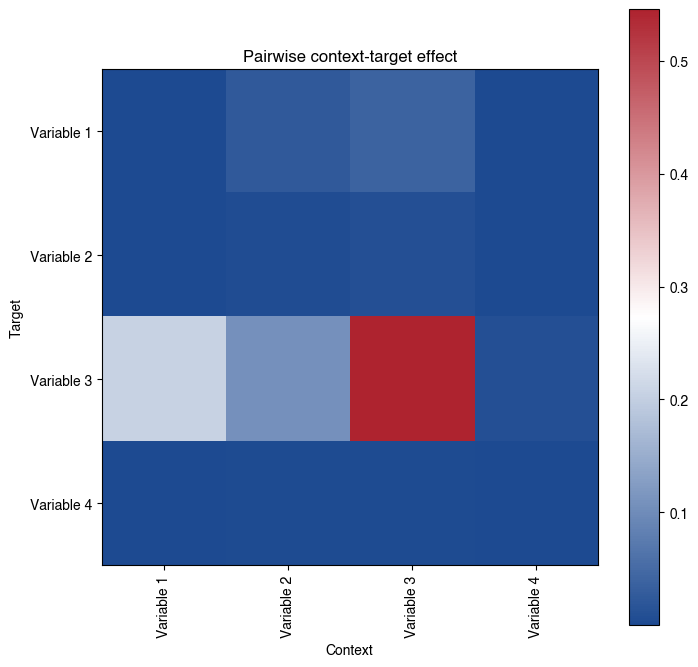

<module 'matplotlib.pyplot' from '/Users/farhadyar/Desktop/mini_transformer/env/lib/python3.10/site-packages/matplotlib/pyplot.py'>

In [6]:
plot_context_predindex_pair_effect(context_predindex_pair_effect, f"exact_{data_str}", "./notebooks/statistical_testing/approx.->exact")

In [7]:
with open(f"./notebooks/statistical_testing/statistical_testing_{data_str}_results_n={n}_batch_size={batch_size}_p={p}_ncum={ncum}_nheads={nheads}_epochs={EPOCHS}_seed={seed}.txt", "a") as f:
    f.write("For combination sample size: all (exact) \n")
    for i in range(avepval.shape[0]):
        f.write(f"Variable {i+1}: {avepval[i]:.4f} ± {stdpval[i]:.2f}\n")

    